In [1]:
# ============================================================
# FINAL-01
# Project results inventory
#
# NO model fitting.
# NO experiment execution.
# ============================================================

from pathlib import Path
import pandas as pd


print("=" * 110)
print("FINAL RESULTS SYNTHESIS — RESULTS INVENTORY")
print("=" * 110)


# ------------------------------------------------------------
# Locate project root
# ------------------------------------------------------------

cwd = Path.cwd().resolve()

project_root = None

for candidate in [cwd, *cwd.parents]:
    if (
        (candidate / "notebooks").exists()
        and
        (candidate / "results").exists()
    ):
        project_root = candidate
        break

assert project_root is not None, (
    "Could not locate project root."
)

results_dir = project_root / "results"

print("\nProject root:")
print(project_root)

print("\nResults directory:")
print(results_dir)


# ------------------------------------------------------------
# Inventory all result artifacts
# ------------------------------------------------------------

result_files = sorted(
    path
    for path in results_dir.rglob("*")
    if path.is_file()
)

inventory = pd.DataFrame(
    {
        "relative_path": [
            str(path.relative_to(project_root))
            for path in result_files
        ],
        "extension": [
            path.suffix.lower()
            for path in result_files
        ],
        "size_kb": [
            round(path.stat().st_size / 1024, 2)
            for path in result_files
        ],
    }
)

print(
    f"\nResult files found: "
    f"{len(inventory):,}"
)

display(inventory)


# ------------------------------------------------------------
# Verify canonical PVOD exports
# ------------------------------------------------------------

pvod_result_dir = (
    results_dir
    / "pvod_external_validation"
)

expected_pvod_exports = [
    "primary_external_validation_summary.csv",
    "secondary_control_point_estimates.csv",
    "secondary_control_bootstrap_summary.csv",
    "mechanism_synthesis.csv",
    "classical_secondary_runtime.csv",
    "neural_secondary_runtime.csv",
]

print("\n" + "=" * 110)
print("PVOD CANONICAL EXPORT AUDIT")
print("=" * 110)

for filename in expected_pvod_exports:

    path = pvod_result_dir / filename

    print(
        f"{filename:45s}",
        path.exists(),
    )

    assert path.exists(), (
        f"Missing canonical PVOD export: {path}"
    )


print("\nFINAL-01: PASSED")
print("No model fitted.")
print("No experiment rerun.")

FINAL RESULTS SYNTHESIS — RESULTS INVENTORY

Project root:
/Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project

Results directory:
/Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results

Result files found: 2,831


,relative_path,extension,size_kb
0,results/notebook09_primary_experiment/baseline...,.csv,4.73
1,results/notebook09_primary_experiment/experime...,.json,1.92
2,results/notebook09_primary_experiment/final_f3...,.csv,0.93
3,results/notebook09_primary_experiment/final_te...,.csv,7614.45
4,results/notebook09_primary_experiment/final_te...,.csv,7600.75
...,...,...,...
2826,results/pvod_secondary_checkpoints_v2/neural/T...,.json,0.50
2827,results/pvod_secondary_checkpoints_v2/neural/T...,.csv,8.18
2828,results/pvod_secondary_checkpoints_v2/neural/T...,.json,0.51
2829,results/pvod_secondary_checkpoints_v2/neural/T...,.csv,8.19



PVOD CANONICAL EXPORT AUDIT
primary_external_validation_summary.csv       True
secondary_control_point_estimates.csv         True
secondary_control_bootstrap_summary.csv       True
mechanism_synthesis.csv                       True
classical_secondary_runtime.csv               True
neural_secondary_runtime.csv                  True

FINAL-01: PASSED
No model fitted.
No experiment rerun.


In [2]:
# ============================================================
# FINAL-02
# Canonical SOLETE + PVOD result-table audit
#
# NO model fitting.
# NO experiment execution.
# ============================================================

from pathlib import Path
import pandas as pd


print("=" * 110)
print("FINAL RESULTS SYNTHESIS — CANONICAL TABLE AUDIT")
print("=" * 110)


# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

cwd = Path.cwd().resolve()

PROJECT_ROOT = None

for candidate in [cwd, *cwd.parents]:
    if (
        (candidate / "notebooks").exists()
        and
        (candidate / "results").exists()
    ):
        PROJECT_ROOT = candidate
        break

assert PROJECT_ROOT is not None

RESULTS_ROOT = PROJECT_ROOT / "results"


# ------------------------------------------------------------
# Canonical tables
# ------------------------------------------------------------

canonical_paths = {

    # ------------------------
    # Phase 1 — SOLETE
    # ------------------------
    "solete_phase1_f3_f4": (
        RESULTS_ROOT
        / "notebook12_phase1_final_synthesis"
        / "publication_f3_f4_effects_numeric.csv"
    ),

    "solete_phase1_model_patterns": (
        RESULTS_ROOT
        / "notebook12_phase1_final_synthesis"
        / "publication_f3_f4_model_patterns.csv"
    ),

    "solete_phase1_transition_counts": (
        RESULTS_ROOT
        / "notebook12_phase1_final_synthesis"
        / "publication_feature_transition_counts.csv"
    ),

    # ------------------------
    # Phase 2A — SOLETE
    # ------------------------
    "solete_phase2_primary": (
        RESULTS_ROOT
        / "notebook13_phase2_f4_representation_analysis"
        / "phase2_four_model_F3_vs_F4_real.csv"
    ),

    "solete_phase2_coding": (
        RESULTS_ROOT
        / "notebook13_phase2_f4_representation_analysis"
        / "phase2_four_model_coding_sensitivity.csv"
    ),

    "solete_phase2_null_controls": (
        RESULTS_ROOT
        / "notebook13_phase2_f4_representation_analysis"
        / "phase2_four_model_null_controls.csv"
    ),

    "solete_phase2_mechanism": (
        RESULTS_ROOT
        / "notebook13_phase2_f4_representation_analysis"
        / "phase2_four_model_mechanism_summary.csv"
    ),

    "solete_phase2_component_evidence": (
        RESULTS_ROOT
        / "notebook13_phase2_f4_representation_analysis"
        / "component_screen"
        / "phase2_component_evidence_counts.csv"
    ),

    "solete_phase2_nonadditivity": (
        RESULTS_ROOT
        / "notebook13_phase2_f4_representation_analysis"
        / "component_screen"
        / "phase2_architecture_component_nonadditivity.csv"
    ),

    # ------------------------
    # External validation — PVOD
    # ------------------------
    "pvod_primary": (
        RESULTS_ROOT
        / "pvod_external_validation"
        / "primary_external_validation_summary.csv"
    ),

    "pvod_secondary": (
        RESULTS_ROOT
        / "pvod_external_validation"
        / "secondary_control_bootstrap_summary.csv"
    ),

    "pvod_mechanism": (
        RESULTS_ROOT
        / "pvod_external_validation"
        / "mechanism_synthesis.csv"
    ),
}


# ------------------------------------------------------------
# Existence audit
# ------------------------------------------------------------

missing = [
    name
    for name, path in canonical_paths.items()
    if not path.exists()
]

assert not missing, (
    "Missing canonical tables: "
    + ", ".join(missing)
)


# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

canonical_tables = {
    name: pd.read_csv(path)
    for name, path in canonical_paths.items()
}


# ------------------------------------------------------------
# Compact schema audit
# ------------------------------------------------------------

audit_rows = []

for name, table in canonical_tables.items():

    audit_rows.append(
        {
            "table": name,
            "rows": len(table),
            "columns": len(table.columns),
            "column_names": " | ".join(table.columns),
        }
    )

canonical_table_audit = pd.DataFrame(audit_rows)

display(canonical_table_audit)


# ------------------------------------------------------------
# Preview each table
# ------------------------------------------------------------

for name, table in canonical_tables.items():

    print("\n" + "=" * 110)
    print(name)
    print("=" * 110)

    print(
        f"Shape: {table.shape}"
    )

    print("\nColumns:")
    for col in table.columns:
        print(" ", col)

    print("\nFirst rows:")
    display(table.head())


print("\nFINAL-02: PASSED")
print("Canonical SOLETE and PVOD synthesis inputs loaded.")
print("No model fitted.")
print("No experiment rerun.")

FINAL RESULTS SYNTHESIS — CANONICAL TABLE AUDIT


,table,rows,columns,column_names
0,solete_phase1_f3_f4,60,9,model | horizon_minutes | scope | F3_to_F4_MAE...
1,solete_phase1_model_patterns,10,8,model | comparisons | F4_lower_MAE_point_count...
2,solete_phase1_transition_counts,4,6,transition | increment | conditions_compared |...
3,solete_phase2_primary,24,18,model | model_family | horizon_minutes | scope...
4,solete_phase2_coding,24,18,model | model_family | horizon_minutes | scope...
5,solete_phase2_null_controls,144,18,model | model_family | horizon_minutes | scope...
6,solete_phase2_mechanism,24,19,model | horizon_minutes | scope | F3_delta_kW ...
7,solete_phase2_component_evidence,20,5,model | component_family | component_lower_MAE...
8,solete_phase2_nonadditivity,4,4,model | mean_absolute_full_minus_sum_kW | max_...
9,pvod_primary,24,13,scope | model | horizon_min | stations | repli...



solete_phase1_f3_f4
Shape: (60, 9)

Columns:
  model
  horizon_minutes
  scope
  F3_to_F4_MAE_improvement_percent
  CI95_low_percent
  CI95_high_percent
  point_direction
  CI_zero_status
  evidence_class

First rows:


,model,horizon_minutes,scope,F3_to_F4_MAE_improvement_percent,CI95_low_percent,CI95_high_percent,point_direction,CI_zero_status,evidence_class
0,Ridge,15,all,-3.436065,-4.794128,-2.141506,F4_higher_MAE,below_zero,CI_below_zero_F4_higher_MAE
1,HGBR,15,all,0.571617,-0.067338,1.316337,F4_lower_MAE,crosses_zero,CI_crosses_zero_point_F4_lower_MAE
2,Extra Trees,15,all,-0.416511,-1.011273,0.123243,F4_higher_MAE,crosses_zero,CI_crosses_zero_point_F4_higher_MAE
3,Random Forest,15,all,-0.183070,-0.479548,0.100633,F4_higher_MAE,crosses_zero,CI_crosses_zero_point_F4_higher_MAE
4,XGBoost,15,all,0.267857,-0.042346,0.584600,F4_lower_MAE,crosses_zero,CI_crosses_zero_point_F4_lower_MAE



solete_phase1_model_patterns
Shape: (10, 8)

Columns:
  model
  comparisons
  F4_lower_MAE_point_count
  F4_higher_MAE_point_count
  CI_above_zero_count
  CI_below_zero_count
  CI_crosses_zero_count
  model_pattern

First rows:


...


pvod_secondary
Shape: (168, 13)

Columns:
  scope
  model
  horizon_min
  control_variant
  comparison_type
  stations
  replicates
  point_delta_MAE
  bootstrap_mean
  bootstrap_median
  ci95_low
  ci95_high
  classification

First rows:


,scope,model,horizon_min,control_variant,comparison_type,stations,replicates,point_delta_MAE,bootstrap_mean,bootstrap_median,ci95_low,ci95_high,classification
0,all,Ridge,15,F4_reference,reference_coding,10,10000,9.326690e-07,9.285671e-07,9.022252e-07,-7.383956e-09,0.000003,crosses_zero
1,all,Ridge,15,F4_shift_17d,alignment_null,10,10000,-4.483878e-03,-4.514239e-03,-4.200331e-03,-1.403840e-02,0.000992,crosses_zero
2,all,Ridge,15,F4_shift_37d,alignment_null,10,10000,8.486471e-05,7.479711e-05,2.110958e-04,-1.752524e-03,0.001284,crosses_zero
3,all,Ridge,15,F4_shift_61d,alignment_null,10,10000,1.658998e-03,1.632021e-03,1.485765e-03,-7.285437e-04,0.005161,crosses_zero
4,all,Ridge,15,F4_perm_1301,alignment_null,10,10000,2.847060e-03,2.852010e-03,2.713042e-03,9.581284e-04,0.005603,control_lower



pvod_mechanism
Shape: (24, 14)

Columns:
  scope
  model
  horizon_min
  primary_F4_minus_F3
  primary_ci95_low
  primary_ci95_high
  primary_classification
  real_minus_reference
  reference_ci95_low
  reference_ci95_high
  reference_classification
  nulls_F4_real_lower
  nulls_control_lower
  nulls_crosses_zero

First rows:


,scope,model,horizon_min,primary_F4_minus_F3,primary_ci95_low,primary_ci95_high,primary_classification,real_minus_reference,reference_ci95_low,reference_ci95_high,reference_classification,nulls_F4_real_lower,nulls_control_lower,nulls_crosses_zero
0,all,LSTM,15,-0.001002,-0.002300,0.000784,crosses_zero,-0.000191,-0.001232,0.000969,crosses_zero,2,0,4
1,all,LSTM,30,-0.004835,-0.009518,-0.001278,F4_lower,0.002587,-0.001361,0.009220,crosses_zero,1,1,4
2,all,LSTM,60,-0.002388,-0.005218,0.000305,crosses_zero,0.002293,-0.000355,0.007199,crosses_zero,1,3,2
3,all,LightGBM,15,0.000124,-0.000071,0.000332,crosses_zero,0.000110,-0.000066,0.000302,crosses_zero,0,4,2
4,all,LightGBM,30,0.000456,-0.000229,0.001611,crosses_zero,0.000461,-0.000087,0.001378,crosses_zero,0,2,4



FINAL-02: PASSED
Canonical SOLETE and PVOD synthesis inputs loaded.
No model fitted.
No experiment rerun.


In [3]:
# ============================================================
# FINAL-03
# Unified SOLETE ↔ PVOD primary F3-vs-F4 evidence table
#
# Canonical sign convention:
#
#   delta_F4_minus_F3
#       < 0  -> F4 lower MAE
#       > 0  -> F3 lower MAE
#
# NO model fitting.
# NO experiment execution.
# ============================================================

import numpy as np
import pandas as pd


print("=" * 115)
print("FINAL RESULTS SYNTHESIS — UNIFIED PRIMARY F3-vs-F4 EVIDENCE")
print("=" * 115)


# ------------------------------------------------------------
# Source tables
# ------------------------------------------------------------

solete_primary = (
    canonical_tables["solete_phase2_primary"]
    .copy()
)

pvod_primary = (
    canonical_tables["pvod_primary"]
    .copy()
)


# ------------------------------------------------------------
# Audit shared grid
# ------------------------------------------------------------

expected_models = {
    "Ridge",
    "LightGBM",
    "LSTM",
    "TCN",
}

expected_horizons = {
    15,
    30,
    60,
}

expected_scopes = {
    "all",
    "daylight",
}


assert set(solete_primary["model"]) == expected_models
assert set(pvod_primary["model"]) == expected_models

assert set(
    solete_primary["horizon_minutes"]
) == expected_horizons

assert set(
    pvod_primary["horizon_min"]
) == expected_horizons

assert set(
    solete_primary["scope"]
) == expected_scopes

assert set(
    pvod_primary["scope"]
) == expected_scopes

assert len(solete_primary) == 24
assert len(pvod_primary) == 24


# ------------------------------------------------------------
# SOLETE
#
# Existing SOLETE definition:
#
# comparator - F4_real
#
# Therefore:
#
# delta_F4_minus_F3
#     = -(comparator - F4_real)
# ------------------------------------------------------------

solete_unified = pd.DataFrame(
    {
        "dataset": "SOLETE",
        "model": solete_primary["model"],
        "architecture_family":
            solete_primary["model_family"],
        "horizon_min":
            solete_primary["horizon_minutes"],
        "scope":
            solete_primary["scope"],

        "delta_F4_minus_F3":
            -solete_primary[
                "delta_MAE_comparator_minus_F4_real_kW"
            ],

        "ci95_low":
            -solete_primary["ci95_high_kW"],

        "ci95_high":
            -solete_primary["ci95_low_kW"],

        "native_metric_unit": "kW",
    }
)


# ------------------------------------------------------------
# PVOD
#
# Existing PVOD definition already is:
#
# F4 - F3
# ------------------------------------------------------------

pvod_unified = pd.DataFrame(
    {
        "dataset": "PVOD",
        "model": pvod_primary["model"],
        "architecture_family":
            pvod_primary["architecture_family"],
        "horizon_min":
            pvod_primary["horizon_min"],
        "scope":
            pvod_primary["scope"],

        "delta_F4_minus_F3":
            pvod_primary["point_delta_MAE"],

        "ci95_low":
            pvod_primary["ci95_low"],

        "ci95_high":
            pvod_primary["ci95_high"],

        "native_metric_unit": "p.u.",
    }
)


# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

primary_cross_dataset = pd.concat(
    [
        solete_unified,
        pvod_unified,
    ],
    ignore_index=True,
)


# ------------------------------------------------------------
# Canonical classification
# ------------------------------------------------------------

primary_cross_dataset[
    "classification"
] = np.select(
    [
        primary_cross_dataset["ci95_high"] < 0,
        primary_cross_dataset["ci95_low"] > 0,
    ],
    [
        "F4_lower",
        "F3_lower",
    ],
    default="crosses_zero",
)


primary_cross_dataset[
    "resolved"
] = (
    primary_cross_dataset["classification"]
    != "crosses_zero"
)


# ------------------------------------------------------------
# Deterministic ordering
# ------------------------------------------------------------

model_order = {
    "Ridge": 0,
    "LightGBM": 1,
    "LSTM": 2,
    "TCN": 3,
}

scope_order = {
    "all": 0,
    "daylight": 1,
}

dataset_order = {
    "SOLETE": 0,
    "PVOD": 1,
}


primary_cross_dataset[
    "_dataset_order"
] = primary_cross_dataset[
    "dataset"
].map(dataset_order)

primary_cross_dataset[
    "_model_order"
] = primary_cross_dataset[
    "model"
].map(model_order)

primary_cross_dataset[
    "_scope_order"
] = primary_cross_dataset[
    "scope"
].map(scope_order)


primary_cross_dataset = (
    primary_cross_dataset
    .sort_values(
        [
            "_dataset_order",
            "_model_order",
            "horizon_min",
            "_scope_order",
        ]
    )
    .drop(
        columns=[
            "_dataset_order",
            "_model_order",
            "_scope_order",
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Structural assertions
# ------------------------------------------------------------

assert len(primary_cross_dataset) == 48

assert not primary_cross_dataset[
    [
        "delta_F4_minus_F3",
        "ci95_low",
        "ci95_high",
    ]
].isna().any().any()

assert (
    primary_cross_dataset["ci95_low"]
    <=
    primary_cross_dataset["ci95_high"]
).all()


# ------------------------------------------------------------
# Evidence-count summary
# ------------------------------------------------------------

primary_evidence_counts = (
    primary_cross_dataset
    .groupby(
        [
            "dataset",
            "model",
        ],
        as_index=False,
    )
    ["classification"]
    .value_counts()
    .pivot(
        index=[
            "dataset",
            "model",
        ],
        columns="classification",
        values="count",
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)


for col in [
    "F4_lower",
    "F3_lower",
    "crosses_zero",
]:
    if col not in primary_evidence_counts.columns:
        primary_evidence_counts[col] = 0


primary_evidence_counts[
    "comparisons"
] = (
    primary_evidence_counts[
        [
            "F4_lower",
            "F3_lower",
            "crosses_zero",
        ]
    ]
    .sum(axis=1)
)


assert (
    primary_evidence_counts[
        "comparisons"
    ]
    .eq(6)
    .all()
)


# ------------------------------------------------------------
# Cross-dataset matched-condition agreement
# ------------------------------------------------------------

matched_primary = (
    primary_cross_dataset
    .pivot(
        index=[
            "model",
            "horizon_min",
            "scope",
        ],
        columns="dataset",
        values="classification",
    )
    .reset_index()
)


assert {
    "SOLETE",
    "PVOD",
}.issubset(
    matched_primary.columns
)


matched_primary[
    "same_classification"
] = (
    matched_primary["SOLETE"]
    ==
    matched_primary["PVOD"]
)


matched_primary[
    "same_resolved_direction"
] = (
    (
        matched_primary["SOLETE"]
        ==
        matched_primary["PVOD"]
    )
    &
    matched_primary[
        "SOLETE"
    ].isin(
        [
            "F4_lower",
            "F3_lower",
        ]
    )
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nUnified primary evidence:")
display(primary_cross_dataset)

print("\nEvidence counts by dataset and model:")
display(primary_evidence_counts)

print("\nMatched SOLETE ↔ PVOD classifications:")
display(matched_primary)


print("\n" + "-" * 115)

print(
    "Matched conditions:",
    len(matched_primary),
)

print(
    "Same exact classification:",
    int(
        matched_primary[
            "same_classification"
        ].sum()
    ),
    "/",
    len(matched_primary),
)

print(
    "Same resolved direction:",
    int(
        matched_primary[
            "same_resolved_direction"
        ].sum()
    ),
    "/",
    len(matched_primary),
)


print("\nFINAL-03: PASSED")
print(
    "Canonical sign convention: "
    "delta_F4_minus_F3 < 0 means F4 lower MAE."
)
print("No model fitted.")
print("No experiment rerun.")

FINAL RESULTS SYNTHESIS — UNIFIED PRIMARY F3-vs-F4 EVIDENCE

Unified primary evidence:


,dataset,model,architecture_family,horizon_min,scope,delta_F4_minus_F3,ci95_low,ci95_high,native_metric_unit,classification,resolved
0,SOLETE,Ridge,classical,15,all,0.010945,0.007035,0.014839,kW,F3_lower,True
1,SOLETE,Ridge,classical,15,daylight,0.007050,0.004321,0.009805,kW,F3_lower,True
2,SOLETE,Ridge,classical,30,all,0.019218,0.012280,0.026424,kW,F3_lower,True
3,SOLETE,Ridge,classical,30,daylight,0.012941,0.008008,0.018007,kW,F3_lower,True
4,SOLETE,Ridge,classical,60,all,0.035300,0.022421,0.048168,kW,F3_lower,True
5,SOLETE,Ridge,classical,60,daylight,0.025369,0.015573,0.035259,kW,F3_lower,True
6,SOLETE,LightGBM,classical,15,all,0.001135,0.000278,0.002061,kW,F3_lower,True
7,SOLETE,LightGBM,classical,15,daylight,0.001799,0.000522,0.003181,kW,F3_lower,True
8,SOLETE,LightGBM,classical,30,all,-0.001769,-0.003158,-0.000529,kW,F4_lower,True
9,SOLETE,LightGBM,classical,30,daylight,-0.002565,-0.004650,-0.000722,kW,F4_lower,True



Evidence counts by dataset and model:


classification,dataset,model,F3_lower,F4_lower,crosses_zero,comparisons
0,PVOD,LSTM,0,3,3,6
1,PVOD,LightGBM,0,0,6,6
2,PVOD,Ridge,6,0,0,6
3,PVOD,TCN,0,5,1,6
4,SOLETE,LSTM,1,2,3,6
5,SOLETE,LightGBM,2,2,2,6
6,SOLETE,Ridge,6,0,0,6
7,SOLETE,TCN,1,3,2,6



Matched SOLETE ↔ PVOD classifications:


dataset,model,horizon_min,scope,PVOD,SOLETE,same_classification,same_resolved_direction
0,LSTM,15,all,crosses_zero,crosses_zero,True,False
1,LSTM,15,daylight,crosses_zero,F4_lower,False,False
2,LSTM,30,all,F4_lower,F4_lower,True,True
3,LSTM,30,daylight,F4_lower,F3_lower,False,False
4,LSTM,60,all,crosses_zero,crosses_zero,True,False
5,LSTM,60,daylight,F4_lower,crosses_zero,False,False
6,LightGBM,15,all,crosses_zero,F3_lower,False,False
7,LightGBM,15,daylight,crosses_zero,F3_lower,False,False
8,LightGBM,30,all,crosses_zero,F4_lower,False,False
9,LightGBM,30,daylight,crosses_zero,F4_lower,False,False



-------------------------------------------------------------------------------------------------------------------
Matched conditions: 24
Same exact classification: 13 / 24
Same resolved direction: 9 / 24

FINAL-03: PASSED
Canonical sign convention: delta_F4_minus_F3 < 0 means F4 lower MAE.
No model fitted.
No experiment rerun.


In [4]:
# ============================================================
# FINAL-04
# Cross-dataset coding + alignment-control synthesis
#
# Canonical sign convention:
#
#   delta_real_minus_control
#       < 0  -> F4_real lower MAE
#       > 0  -> control lower MAE
#
# NO model fitting.
# NO experiment execution.
# ============================================================

import numpy as np
import pandas as pd


print("=" * 115)
print("FINAL RESULTS SYNTHESIS — CROSS-DATASET MECHANISM CONTROLS")
print("=" * 115)


# ------------------------------------------------------------
# Source tables
# ------------------------------------------------------------

solete_coding = canonical_tables["solete_phase2_coding"].copy()
solete_nulls = canonical_tables["solete_phase2_null_controls"].copy()

pvod_secondary = canonical_tables["pvod_secondary"].copy()


# ------------------------------------------------------------
# SOLETE — coding reference
#
# Existing sign:
# comparator - F4_real
#
# Convert to:
# F4_real - comparator
# ------------------------------------------------------------

solete_coding_u = pd.DataFrame(
    {
        "dataset": "SOLETE",
        "model": solete_coding["model"],
        "horizon_min": solete_coding["horizon_minutes"],
        "scope": solete_coding["scope"],
        "control_variant": solete_coding["comparator"],
        "comparison_type": "reference_coding",

        "delta_real_minus_control":
            -solete_coding[
                "delta_MAE_comparator_minus_F4_real_kW"
            ],

        "ci95_low":
            -solete_coding["ci95_high_kW"],

        "ci95_high":
            -solete_coding["ci95_low_kW"],

        "native_metric_unit": "kW",
    }
)


# ------------------------------------------------------------
# SOLETE — shift/permutation controls
# ------------------------------------------------------------

solete_nulls_u = pd.DataFrame(
    {
        "dataset": "SOLETE",
        "model": solete_nulls["model"],
        "horizon_min": solete_nulls["horizon_minutes"],
        "scope": solete_nulls["scope"],
        "control_variant": solete_nulls["comparator"],
        "comparison_type": "alignment_null",

        "delta_real_minus_control":
            -solete_nulls[
                "delta_MAE_comparator_minus_F4_real_kW"
            ],

        "ci95_low":
            -solete_nulls["ci95_high_kW"],

        "ci95_high":
            -solete_nulls["ci95_low_kW"],

        "native_metric_unit": "kW",
    }
)


# ------------------------------------------------------------
# PVOD
#
# Existing sign already is:
# F4_real - control
# ------------------------------------------------------------

pvod_u = pd.DataFrame(
    {
        "dataset": "PVOD",
        "model": pvod_secondary["model"],
        "horizon_min": pvod_secondary["horizon_min"],
        "scope": pvod_secondary["scope"],
        "control_variant": pvod_secondary["control_variant"],
        "comparison_type": pvod_secondary["comparison_type"],

        "delta_real_minus_control":
            pvod_secondary["point_delta_MAE"],

        "ci95_low":
            pvod_secondary["ci95_low"],

        "ci95_high":
            pvod_secondary["ci95_high"],

        "native_metric_unit": "p.u.",
    }
)


# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

mechanism_cross_dataset = pd.concat(
    [
        solete_coding_u,
        solete_nulls_u,
        pvod_u,
    ],
    ignore_index=True,
)


# ------------------------------------------------------------
# Canonical classification
# ------------------------------------------------------------

mechanism_cross_dataset[
    "classification"
] = np.select(
    [
        mechanism_cross_dataset["ci95_high"] < 0,
        mechanism_cross_dataset["ci95_low"] > 0,
    ],
    [
        "F4_real_lower",
        "control_lower",
    ],
    default="crosses_zero",
)


# ------------------------------------------------------------
# Structural audits
# ------------------------------------------------------------

expected_counts = {
    ("SOLETE", "reference_coding"): 24,
    ("SOLETE", "alignment_null"): 144,
    ("PVOD", "reference_coding"): 24,
    ("PVOD", "alignment_null"): 144,
}

actual_counts = (
    mechanism_cross_dataset
    .groupby(
        ["dataset", "comparison_type"]
    )
    .size()
    .to_dict()
)

assert actual_counts == expected_counts


# ------------------------------------------------------------
# Evidence counts
# ------------------------------------------------------------

mechanism_evidence_counts = (
    mechanism_cross_dataset
    .groupby(
        [
            "dataset",
            "comparison_type",
            "classification",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)


for col in [
    "F4_real_lower",
    "control_lower",
    "crosses_zero",
]:
    if col not in mechanism_evidence_counts.columns:
        mechanism_evidence_counts[col] = 0


mechanism_evidence_counts[
    "comparisons"
] = (
    mechanism_evidence_counts[
        [
            "F4_real_lower",
            "control_lower",
            "crosses_zero",
        ]
    ]
    .sum(axis=1)
)


# ------------------------------------------------------------
# Per-model alignment-null counts
# ------------------------------------------------------------

alignment_model_counts = (
    mechanism_cross_dataset[
        mechanism_cross_dataset[
            "comparison_type"
        ].eq("alignment_null")
    ]
    .groupby(
        [
            "dataset",
            "model",
            "classification",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)


for col in [
    "F4_real_lower",
    "control_lower",
    "crosses_zero",
]:
    if col not in alignment_model_counts.columns:
        alignment_model_counts[col] = 0


alignment_model_counts[
    "comparisons"
] = (
    alignment_model_counts[
        [
            "F4_real_lower",
            "control_lower",
            "crosses_zero",
        ]
    ]
    .sum(axis=1)
)


assert alignment_model_counts[
    "comparisons"
].eq(36).all()


# ------------------------------------------------------------
# Matched reference-coding comparison
# ------------------------------------------------------------

reference_matched = (
    mechanism_cross_dataset[
        mechanism_cross_dataset[
            "comparison_type"
        ].eq("reference_coding")
    ]
    .pivot(
        index=[
            "model",
            "horizon_min",
            "scope",
        ],
        columns="dataset",
        values="classification",
    )
    .reset_index()
)


reference_matched[
    "same_classification"
] = (
    reference_matched["SOLETE"]
    ==
    reference_matched["PVOD"]
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nOverall mechanism evidence counts:")
display(mechanism_evidence_counts)

print("\nAlignment-null evidence by dataset and model:")
display(alignment_model_counts)

print("\nMatched reference-coding evidence:")
display(reference_matched)


print("\n" + "-" * 115)

print(
    "Reference-coding exact agreement:",
    int(
        reference_matched[
            "same_classification"
        ].sum()
    ),
    "/",
    len(reference_matched),
)


for dataset in ["SOLETE", "PVOD"]:

    subset = mechanism_evidence_counts[
        (
            mechanism_evidence_counts["dataset"]
            == dataset
        )
        &
        (
            mechanism_evidence_counts[
                "comparison_type"
            ]
            == "alignment_null"
        )
    ]

    assert len(subset) == 1

    row = subset.iloc[0]

    print(
        f"{dataset} alignment nulls:",
        f"F4_real_lower={int(row['F4_real_lower'])},",
        f"control_lower={int(row['control_lower'])},",
        f"crosses_zero={int(row['crosses_zero'])}",
    )


print("\nFINAL-04: PASSED")
print(
    "Canonical mechanism sign: "
    "delta_real_minus_control < 0 means F4_real lower MAE."
)
print("No model fitted.")
print("No experiment rerun.")

FINAL RESULTS SYNTHESIS — CROSS-DATASET MECHANISM CONTROLS

Overall mechanism evidence counts:


classification,dataset,comparison_type,F4_real_lower,control_lower,crosses_zero,comparisons
0,PVOD,alignment_null,9,42,93,144
1,PVOD,reference_coding,0,0,24,24
2,SOLETE,alignment_null,35,58,51,144
3,SOLETE,reference_coding,8,7,9,24



Alignment-null evidence by dataset and model:


classification,dataset,model,F4_real_lower,control_lower,crosses_zero,comparisons
0,PVOD,LSTM,5,6,25,36
1,PVOD,LightGBM,0,15,21,36
2,PVOD,Ridge,0,20,16,36
3,PVOD,TCN,4,1,31,36
4,SOLETE,LSTM,11,16,9,36
5,SOLETE,LightGBM,12,0,24,36
6,SOLETE,Ridge,8,18,10,36
7,SOLETE,TCN,4,24,8,36



Matched reference-coding evidence:


dataset,model,horizon_min,scope,PVOD,SOLETE,same_classification
0,LSTM,15,all,crosses_zero,control_lower,False
1,LSTM,15,daylight,crosses_zero,control_lower,False
2,LSTM,30,all,crosses_zero,control_lower,False
3,LSTM,30,daylight,crosses_zero,control_lower,False
4,LSTM,60,all,crosses_zero,F4_real_lower,False
5,LSTM,60,daylight,crosses_zero,F4_real_lower,False
6,LightGBM,15,all,crosses_zero,crosses_zero,True
7,LightGBM,15,daylight,crosses_zero,crosses_zero,True
8,LightGBM,30,all,crosses_zero,F4_real_lower,False
9,LightGBM,30,daylight,crosses_zero,F4_real_lower,False



-------------------------------------------------------------------------------------------------------------------
Reference-coding exact agreement: 9 / 24
SOLETE alignment nulls: F4_real_lower=35, control_lower=58, crosses_zero=51
PVOD alignment nulls: F4_real_lower=9, control_lower=42, crosses_zero=93

FINAL-04: PASSED
Canonical mechanism sign: delta_real_minus_control < 0 means F4_real lower MAE.
No model fitted.
No experiment rerun.


In [5]:
# ============================================================
# FINAL-05
# Final cross-dataset evidence matrix
#
# Summarizes:
#   1. primary F3 vs F4 evidence
#   2. reference-coding evidence
#   3. alignment-null evidence
#
# NO model fitting.
# NO experiment execution.
# ============================================================

import pandas as pd


print("=" * 115)
print("FINAL RESULTS SYNTHESIS — FINAL CROSS-DATASET EVIDENCE MATRIX")
print("=" * 115)


# ------------------------------------------------------------
# Primary evidence counts
# ------------------------------------------------------------

primary_summary = (
    primary_evidence_counts[
        [
            "dataset",
            "model",
            "F4_lower",
            "F3_lower",
            "crosses_zero",
        ]
    ]
    .rename(
        columns={
            "F4_lower": "primary_F4_lower",
            "F3_lower": "primary_F3_lower",
            "crosses_zero": "primary_crosses_zero",
        }
    )
)


# ------------------------------------------------------------
# Reference-coding evidence counts
# ------------------------------------------------------------

reference_summary = (
    mechanism_cross_dataset[
        mechanism_cross_dataset[
            "comparison_type"
        ].eq("reference_coding")
    ]
    .groupby(
        [
            "dataset",
            "model",
            "classification",
        ]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)


for col in [
    "F4_real_lower",
    "control_lower",
    "crosses_zero",
]:
    if col not in reference_summary.columns:
        reference_summary[col] = 0


reference_summary = (
    reference_summary[
        [
            "dataset",
            "model",
            "F4_real_lower",
            "control_lower",
            "crosses_zero",
        ]
    ]
    .rename(
        columns={
            "F4_real_lower":
                "reference_F4_real_lower",
            "control_lower":
                "reference_control_lower",
            "crosses_zero":
                "reference_crosses_zero",
        }
    )
)


# ------------------------------------------------------------
# Alignment-null evidence counts
# ------------------------------------------------------------

alignment_summary = (
    alignment_model_counts[
        [
            "dataset",
            "model",
            "F4_real_lower",
            "control_lower",
            "crosses_zero",
        ]
    ]
    .rename(
        columns={
            "F4_real_lower":
                "null_F4_real_lower",
            "control_lower":
                "null_control_lower",
            "crosses_zero":
                "null_crosses_zero",
        }
    )
)


# ------------------------------------------------------------
# Merge
# ------------------------------------------------------------

final_evidence_matrix = (
    primary_summary
    .merge(
        reference_summary,
        on=["dataset", "model"],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        alignment_summary,
        on=["dataset", "model"],
        how="inner",
        validate="one_to_one",
    )
)


# ------------------------------------------------------------
# Structural assertions
# ------------------------------------------------------------

assert len(final_evidence_matrix) == 8

assert (
    final_evidence_matrix[
        [
            "primary_F4_lower",
            "primary_F3_lower",
            "primary_crosses_zero",
        ]
    ]
    .sum(axis=1)
    .eq(6)
    .all()
)

assert (
    final_evidence_matrix[
        [
            "reference_F4_real_lower",
            "reference_control_lower",
            "reference_crosses_zero",
        ]
    ]
    .sum(axis=1)
    .eq(6)
    .all()
)

assert (
    final_evidence_matrix[
        [
            "null_F4_real_lower",
            "null_control_lower",
            "null_crosses_zero",
        ]
    ]
    .sum(axis=1)
    .eq(36)
    .all()
)


# ------------------------------------------------------------
# Architecture-level interpretation labels
#
# These are descriptive labels derived only from the
# observed count patterns; they are not causal claims.
# ------------------------------------------------------------

def summarize_primary(row):

    if row["primary_F3_lower"] == 6:
        return "consistent_F3_advantage"

    if row["primary_F4_lower"] >= 5:
        return "strong_F4_tendency"

    if row["primary_crosses_zero"] == 6:
        return "fully_unresolved"

    return "mixed_or_context_dependent"


def summarize_alignment(row):

    if row["null_control_lower"] > row["null_F4_real_lower"]:
        return "controls_more_often_lower"

    if row["null_F4_real_lower"] > row["null_control_lower"]:
        return "real_F4_more_often_lower"

    return "balanced_or_unresolved"


final_evidence_matrix[
    "primary_pattern"
] = final_evidence_matrix.apply(
    summarize_primary,
    axis=1,
)

final_evidence_matrix[
    "alignment_pattern"
] = final_evidence_matrix.apply(
    summarize_alignment,
    axis=1,
)


# ------------------------------------------------------------
# Deterministic ordering
# ------------------------------------------------------------

dataset_order = {
    "SOLETE": 0,
    "PVOD": 1,
}

model_order = {
    "Ridge": 0,
    "LightGBM": 1,
    "LSTM": 2,
    "TCN": 3,
}

final_evidence_matrix[
    "_dataset_order"
] = final_evidence_matrix[
    "dataset"
].map(dataset_order)

final_evidence_matrix[
    "_model_order"
] = final_evidence_matrix[
    "model"
].map(model_order)

final_evidence_matrix = (
    final_evidence_matrix
    .sort_values(
        [
            "_dataset_order",
            "_model_order",
        ]
    )
    .drop(
        columns=[
            "_dataset_order",
            "_model_order",
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Cross-dataset architecture comparison
# ------------------------------------------------------------

architecture_cross_dataset = (
    final_evidence_matrix[
        [
            "dataset",
            "model",
            "primary_pattern",
            "alignment_pattern",
        ]
    ]
    .pivot(
        index="model",
        columns="dataset",
        values=[
            "primary_pattern",
            "alignment_pattern",
        ],
    )
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nFinal evidence matrix:")
display(final_evidence_matrix)

print("\nArchitecture-level cross-dataset comparison:")
display(architecture_cross_dataset)


print("\n" + "-" * 115)

print("Primary totals by dataset:")

display(
    final_evidence_matrix
    .groupby("dataset")[
        [
            "primary_F4_lower",
            "primary_F3_lower",
            "primary_crosses_zero",
        ]
    ]
    .sum()
)


print("\nAlignment-null totals by dataset:")

display(
    final_evidence_matrix
    .groupby("dataset")[
        [
            "null_F4_real_lower",
            "null_control_lower",
            "null_crosses_zero",
        ]
    ]
    .sum()
)


print("\nFINAL-05: PASSED")
print("Final descriptive evidence matrix constructed.")
print("No model fitted.")
print("No experiment rerun.")

FINAL RESULTS SYNTHESIS — FINAL CROSS-DATASET EVIDENCE MATRIX

Final evidence matrix:


classification,dataset,model,primary_F4_lower,primary_F3_lower,primary_crosses_zero,reference_F4_real_lower,reference_control_lower,reference_crosses_zero,null_F4_real_lower,null_control_lower,null_crosses_zero,primary_pattern,alignment_pattern
0,SOLETE,Ridge,0,6,0,0,0,6,8,18,10,consistent_F3_advantage,controls_more_often_lower
1,SOLETE,LightGBM,2,2,2,2,1,3,12,0,24,mixed_or_context_dependent,real_F4_more_often_lower
2,SOLETE,LSTM,2,1,3,2,4,0,11,16,9,mixed_or_context_dependent,controls_more_often_lower
3,SOLETE,TCN,3,1,2,4,2,0,4,24,8,mixed_or_context_dependent,controls_more_often_lower
4,PVOD,Ridge,0,6,0,0,0,6,0,20,16,consistent_F3_advantage,controls_more_often_lower
5,PVOD,LightGBM,0,0,6,0,0,6,0,15,21,fully_unresolved,controls_more_often_lower
6,PVOD,LSTM,3,0,3,0,0,6,5,6,25,mixed_or_context_dependent,controls_more_often_lower
7,PVOD,TCN,5,0,1,0,0,6,4,1,31,strong_F4_tendency,real_F4_more_often_lower



Architecture-level cross-dataset comparison:


primary_pattern                              \
dataset                         PVOD                      SOLETE   
model                                                              
LSTM      mixed_or_context_dependent  mixed_or_context_dependent   
LightGBM            fully_unresolved  mixed_or_context_dependent   
Ridge        consistent_F3_advantage     consistent_F3_advantage   
TCN               strong_F4_tendency  mixed_or_context_dependent   

                  alignment_pattern                             
dataset                        PVOD                     SOLETE  
model                                                           
LSTM      controls_more_often_lower  controls_more_often_lower  
LightGBM  controls_more_often_lower   real_F4_more_often_lower  
Ridge     controls_more_often_lower  controls_more_often_lower  
TCN        real_F4_more_often_lower  controls_more_often_lower


-------------------------------------------------------------------------------------------------------------------
Primary totals by dataset:


classification,primary_F4_lower,primary_F3_lower,primary_crosses_zero
dataset,,,
PVOD,8,6,10
SOLETE,7,10,7



Alignment-null totals by dataset:


classification,null_F4_real_lower,null_control_lower,null_crosses_zero
dataset,,,
PVOD,9,42,93
SOLETE,35,58,51



FINAL-05: PASSED
Final descriptive evidence matrix constructed.
No model fitted.
No experiment rerun.


FINAL RESULTS SYNTHESIS — FIGURE 1 LAYOUT CORRECTION


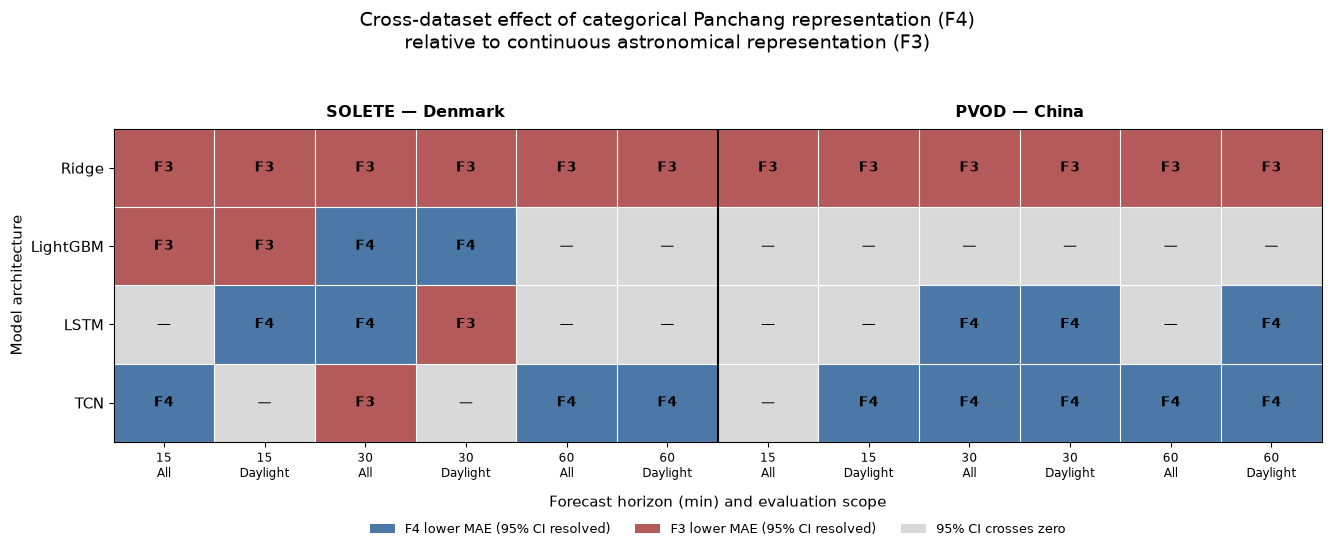


FINAL-06R: PASSED
Figure 1 publication layout corrected.
Underlying evidence unchanged.


In [7]:
# ============================================================
# FINAL-06R
# Figure 1 — publication-layout correction
#
# Same data and classifications as FINAL-06.
# Layout only.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch


print("=" * 115)
print("FINAL RESULTS SYNTHESIS — FIGURE 1 LAYOUT CORRECTION")
print("=" * 115)


# ------------------------------------------------------------
# Reconstruct plotting matrix from locked FINAL-03 results
# ------------------------------------------------------------

model_order = [
    "Ridge",
    "LightGBM",
    "LSTM",
    "TCN",
]

condition_order = [
    ("SOLETE", 15, "all"),
    ("SOLETE", 15, "daylight"),
    ("SOLETE", 30, "all"),
    ("SOLETE", 30, "daylight"),
    ("SOLETE", 60, "all"),
    ("SOLETE", 60, "daylight"),

    ("PVOD", 15, "all"),
    ("PVOD", 15, "daylight"),
    ("PVOD", 30, "all"),
    ("PVOD", 30, "daylight"),
    ("PVOD", 60, "all"),
    ("PVOD", 60, "daylight"),
]


classification_to_value = {
    "F3_lower": -1,
    "crosses_zero": 0,
    "F4_lower": 1,
}


matrix = np.empty(
    (
        len(model_order),
        len(condition_order),
    ),
    dtype=int,
)


for i, model in enumerate(model_order):

    for j, (
        dataset,
        horizon,
        scope,
    ) in enumerate(condition_order):

        row = primary_cross_dataset[
            (primary_cross_dataset["model"] == model)
            &
            (primary_cross_dataset["dataset"] == dataset)
            &
            (primary_cross_dataset["horizon_min"] == horizon)
            &
            (primary_cross_dataset["scope"] == scope)
        ]

        assert len(row) == 1

        matrix[i, j] = classification_to_value[
            row.iloc[0]["classification"]
        ]


# ------------------------------------------------------------
# Colour mapping
# ------------------------------------------------------------

cmap = ListedColormap(
    [
        "#B45A5A",   # F3 lower
        "#D9D9D9",   # unresolved
        "#4C78A8",   # F4 lower
    ]
)

norm = BoundaryNorm(
    [-1.5, -0.5, 0.5, 1.5],
    cmap.N,
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13.5, 5.8)
)

ax.imshow(
    matrix,
    cmap=cmap,
    norm=norm,
    aspect="auto",
)


# ------------------------------------------------------------
# Cell annotations
# ------------------------------------------------------------

symbol_map = {
    -1: "F3",
    0: "—",
    1: "F4",
}


for i in range(matrix.shape[0]):

    for j in range(matrix.shape[1]):

        value = matrix[i, j]

        ax.text(
            j,
            i,
            symbol_map[value],
            ha="center",
            va="center",
            fontsize=10,
            fontweight=(
                "bold"
                if value != 0
                else "normal"
            ),
        )


# ------------------------------------------------------------
# Y axis
# ------------------------------------------------------------

ax.set_yticks(
    np.arange(len(model_order))
)

ax.set_yticklabels(
    model_order,
    fontsize=11,
)

ax.set_ylabel(
    "Model architecture",
    fontsize=11,
)


# ------------------------------------------------------------
# X axis
# ------------------------------------------------------------

column_labels = []

for _, horizon, scope in condition_order:

    scope_label = (
        "All"
        if scope == "all"
        else "Daylight"
    )

    column_labels.append(
        f"{horizon}\n{scope_label}"
    )


ax.set_xticks(
    np.arange(len(condition_order))
)

ax.set_xticklabels(
    column_labels,
    fontsize=8.5,
)

ax.set_xlabel(
    "Forecast horizon (min) and evaluation scope",
    fontsize=11,
    labelpad=10,
)


# ------------------------------------------------------------
# Dataset separator
# ------------------------------------------------------------

ax.axvline(
    5.5,
    linewidth=1.5,
    color="black",
)


# ------------------------------------------------------------
# Dataset headers
#
# Use axes coordinates so they remain independent of
# heatmap row coordinates and cannot collide with the matrix.
# ------------------------------------------------------------

ax.text(
    0.25,
    1.025,
    "SOLETE — Denmark",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11.5,
    fontweight="bold",
)

ax.text(
    0.75,
    1.025,
    "PVOD — China",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11.5,
    fontweight="bold",
)


# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------

fig.suptitle(
    "Cross-dataset effect of categorical Panchang representation (F4)\n"
    "relative to continuous astronomical representation (F3)",
    fontsize=13.5,
    y=0.985,
)


# ------------------------------------------------------------
# Cell grid
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(
        -0.5,
        matrix.shape[1],
        1,
    ),
    minor=True,
)

ax.set_yticks(
    np.arange(
        -0.5,
        matrix.shape[0],
        1,
    ),
    minor=True,
)

ax.grid(
    which="minor",
    linewidth=0.8,
    color="white",
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor="#4C78A8",
        label="F4 lower MAE (95% CI resolved)",
    ),
    Patch(
        facecolor="#B45A5A",
        label="F3 lower MAE (95% CI resolved)",
    ),
    Patch(
        facecolor="#D9D9D9",
        label="95% CI crosses zero",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
    fontsize=9,
)


# Explicit margins are safer than tight_layout for
# a figure containing both suptitle and group headers.
fig.subplots_adjust(
    top=0.78,
    bottom=0.24,
    left=0.09,
    right=0.985,
)


# ------------------------------------------------------------
# Export — overwrite FINAL-06 figure files
# ------------------------------------------------------------

figure_base = (
    FINAL_RESULT_DIR
    / "figure_cross_dataset_primary_evidence"
)

fig.savefig(
    figure_base.with_suffix(".png"),
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_base.with_suffix(".pdf"),
    bbox_inches="tight",
)

fig.savefig(
    figure_base.with_suffix(".svg"),
    bbox_inches="tight",
)

plt.show()


print("\nFINAL-06R: PASSED")
print("Figure 1 publication layout corrected.")
print("Underlying evidence unchanged.")

FINAL RESULTS SYNTHESIS — FIGURE 2
Cross-dataset alignment-null evidence


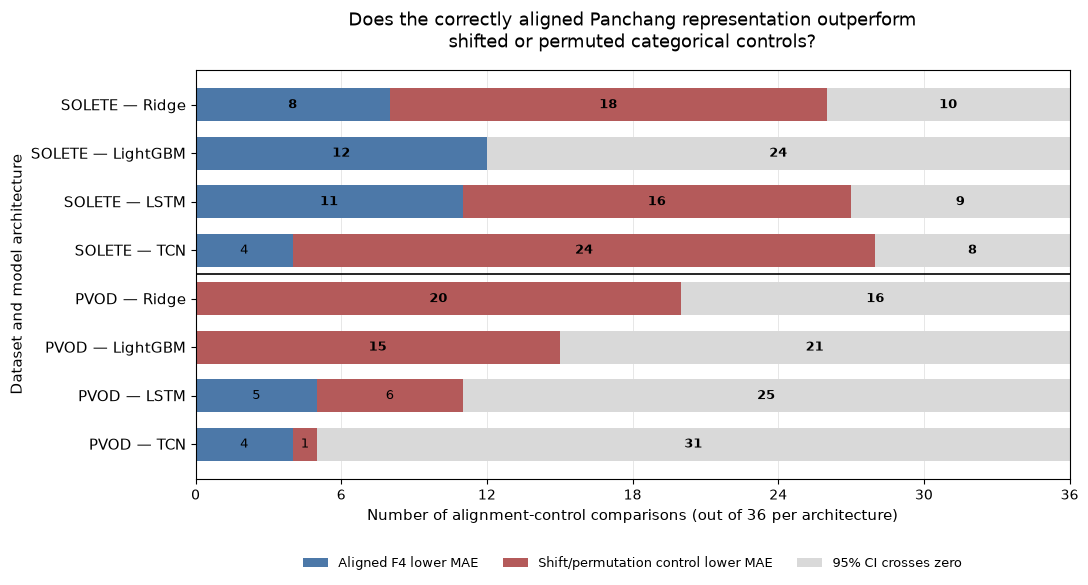


Exported:
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook15_final_results_synthesis/figure_cross_dataset_alignment_null_evidence.png
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook15_final_results_synthesis/figure_cross_dataset_alignment_null_evidence.pdf
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook15_final_results_synthesis/figure_cross_dataset_alignment_null_evidence.svg
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook15_final_results_synthesis/figure_cross_dataset_alignment_null_evidence_data.csv

FINAL-07: PASSED
Figure 2 exported.
No model fitted.
No experiment rerun.


In [8]:
# ============================================================
# FINAL-07
# Figure 2 — Cross-dataset alignment-null evidence
#
# Each architecture has 36 comparisons:
#   3 horizons × 2 scopes × 6 alignment controls
#
# Categories:
#   F4_real_lower  -> aligned F4_real lower MAE
#   control_lower  -> shifted/permuted control lower MAE
#   crosses_zero   -> 95% CI crosses zero
#
# NO model fitting.
# NO experiment execution.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch


print("=" * 115)
print("FINAL RESULTS SYNTHESIS — FIGURE 2")
print("Cross-dataset alignment-null evidence")
print("=" * 115)


# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

figure2_data = (
    alignment_model_counts[
        [
            "dataset",
            "model",
            "F4_real_lower",
            "control_lower",
            "crosses_zero",
            "comparisons",
        ]
    ]
    .copy()
)


dataset_order = {
    "SOLETE": 0,
    "PVOD": 1,
}

model_order = {
    "Ridge": 0,
    "LightGBM": 1,
    "LSTM": 2,
    "TCN": 3,
}


figure2_data["_dataset_order"] = (
    figure2_data["dataset"]
    .map(dataset_order)
)

figure2_data["_model_order"] = (
    figure2_data["model"]
    .map(model_order)
)


figure2_data = (
    figure2_data
    .sort_values(
        [
            "_dataset_order",
            "_model_order",
        ]
    )
    .drop(
        columns=[
            "_dataset_order",
            "_model_order",
        ]
    )
    .reset_index(drop=True)
)


assert len(figure2_data) == 8
assert figure2_data["comparisons"].eq(36).all()


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

labels = [
    f"{row.dataset} — {row.model}"
    for row in figure2_data.itertuples()
]


y = np.arange(len(figure2_data))


f4_counts = (
    figure2_data["F4_real_lower"]
    .to_numpy()
)

control_counts = (
    figure2_data["control_lower"]
    .to_numpy()
)

unresolved_counts = (
    figure2_data["crosses_zero"]
    .to_numpy()
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11.5, 6.4)
)


bar_height = 0.68


bars_f4 = ax.barh(
    y,
    f4_counts,
    height=bar_height,
    label="Aligned F4 lower MAE",
    color="#4C78A8",
)

bars_control = ax.barh(
    y,
    control_counts,
    left=f4_counts,
    height=bar_height,
    label="Shift/permutation control lower MAE",
    color="#B45A5A",
)

bars_unresolved = ax.barh(
    y,
    unresolved_counts,
    left=(
        f4_counts
        +
        control_counts
    ),
    height=bar_height,
    label="95% CI crosses zero",
    color="#D9D9D9",
)


# ------------------------------------------------------------
# Count annotations
# ------------------------------------------------------------

segments = [
    (
        f4_counts,
        np.zeros_like(f4_counts),
    ),
    (
        control_counts,
        f4_counts,
    ),
    (
        unresolved_counts,
        f4_counts + control_counts,
    ),
]


for values, lefts in segments:

    for i, (value, left) in enumerate(
        zip(values, lefts)
    ):

        if value == 0:
            continue

        ax.text(
            left + value / 2,
            i,
            str(int(value)),
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight=(
                "bold"
                if value >= 8
                else "normal"
            ),
        )


# ------------------------------------------------------------
# Dataset separator
# ------------------------------------------------------------

ax.axhline(
    3.5,
    color="black",
    linewidth=1.2,
)


# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_yticks(y)
ax.set_yticklabels(
    labels,
    fontsize=10.5,
)

ax.invert_yaxis()


ax.set_xlim(0, 36)

ax.set_xticks(
    np.arange(
        0,
        37,
        6,
    )
)

ax.set_xlabel(
    "Number of alignment-control comparisons (out of 36 per architecture)",
    fontsize=11,
)

ax.set_ylabel(
    "Dataset and model architecture",
    fontsize=11,
)


ax.set_title(
    "Does the correctly aligned Panchang representation outperform\n"
    "shifted or permuted categorical controls?",
    fontsize=13,
    pad=16,
)


# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

ax.grid(
    axis="x",
    linewidth=0.6,
    alpha=0.35,
)

ax.set_axisbelow(True)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor="#4C78A8",
        label="Aligned F4 lower MAE",
    ),
    Patch(
        facecolor="#B45A5A",
        label="Shift/permutation control lower MAE",
    ),
    Patch(
        facecolor="#D9D9D9",
        label="95% CI crosses zero",
    ),
]


ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=3,
    frameon=False,
    fontsize=9,
)


fig.subplots_adjust(
    left=0.22,
    right=0.98,
    top=0.84,
    bottom=0.20,
)


# ------------------------------------------------------------
# Export
# ------------------------------------------------------------

figure_base = (
    FINAL_RESULT_DIR
    / "figure_cross_dataset_alignment_null_evidence"
)


fig.savefig(
    figure_base.with_suffix(".png"),
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_base.with_suffix(".pdf"),
    bbox_inches="tight",
)

fig.savefig(
    figure_base.with_suffix(".svg"),
    bbox_inches="tight",
)


figure2_data.to_csv(
    FINAL_RESULT_DIR
    / "figure_cross_dataset_alignment_null_evidence_data.csv",
    index=False,
)


plt.show()


print("\nExported:")

for suffix in [
    ".png",
    ".pdf",
    ".svg",
]:
    print(
        " ",
        figure_base.with_suffix(suffix)
    )

print(
    " ",
    FINAL_RESULT_DIR
    / "figure_cross_dataset_alignment_null_evidence_data.csv"
)


print("\nFINAL-07: PASSED")
print("Figure 2 exported.")
print("No model fitted.")
print("No experiment rerun.")

FINAL RESULTS SYNTHESIS — FIGURE 3
SOLETE architecture-level Panchang component non-additivity


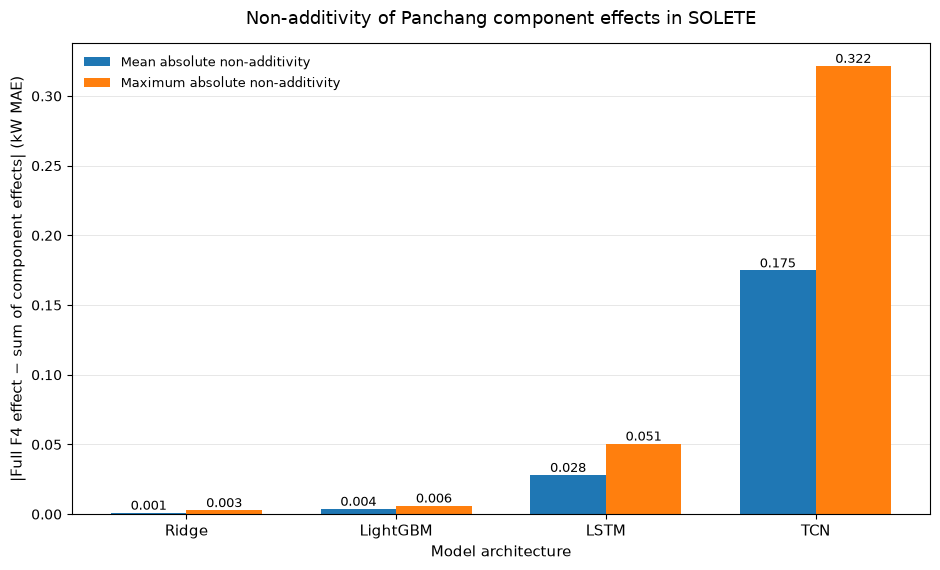


Underlying values:


,model,mean_absolute_full_minus_sum_kW,max_absolute_full_minus_sum_kW,mean_full_F4_delta_kW
0,Ridge,0.001035,0.002893,-0.018470
1,LightGBM,0.003848,0.006166,0.000478
2,LSTM,0.028157,0.050626,0.003255
3,TCN,0.174889,0.321626,0.013621



FINAL-08: PASSED
Figure 3 exported.
No model fitted.
No experiment rerun.


In [9]:
# ============================================================
# FINAL-08
# Figure 3 — SOLETE component interaction / non-additivity
#
# Shows how strongly the observed full-F4 effect differs from
# the sum of individual Panchang-family component effects.
#
# Larger values -> stronger non-additive representation effects.
#
# SOLETE Phase 2A only.
#
# NO model fitting.
# NO experiment execution.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


print("=" * 115)
print("FINAL RESULTS SYNTHESIS — FIGURE 3")
print("SOLETE architecture-level Panchang component non-additivity")
print("=" * 115)


# ------------------------------------------------------------
# Source data
# ------------------------------------------------------------

figure3_data = (
    canonical_tables[
        "solete_phase2_nonadditivity"
    ]
    .copy()
)


model_order = [
    "Ridge",
    "LightGBM",
    "LSTM",
    "TCN",
]


figure3_data["model"] = pd.Categorical(
    figure3_data["model"],
    categories=model_order,
    ordered=True,
)

figure3_data = (
    figure3_data
    .sort_values("model")
    .reset_index(drop=True)
)


assert len(figure3_data) == 4


# ------------------------------------------------------------
# Values
# ------------------------------------------------------------

models = (
    figure3_data["model"]
    .astype(str)
    .to_list()
)

mean_nonadditivity = (
    figure3_data[
        "mean_absolute_full_minus_sum_kW"
    ]
    .to_numpy()
)

max_nonadditivity = (
    figure3_data[
        "max_absolute_full_minus_sum_kW"
    ]
    .to_numpy()
)


x = np.arange(len(models))

width = 0.36


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9.5, 5.8)
)


bars_mean = ax.bar(
    x - width / 2,
    mean_nonadditivity,
    width,
    label="Mean absolute non-additivity",
)

bars_max = ax.bar(
    x + width / 2,
    max_nonadditivity,
    width,
    label="Maximum absolute non-additivity",
)


# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------

for bars in [
    bars_mean,
    bars_max,
]:

    for bar in bars:

        value = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            value,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )


# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    models,
    fontsize=11,
)


ax.set_ylabel(
    "|Full F4 effect − sum of component effects| (kW MAE)",
    fontsize=11,
)

ax.set_xlabel(
    "Model architecture",
    fontsize=11,
)


ax.set_title(
    "Non-additivity of Panchang component effects in SOLETE",
    fontsize=13,
    pad=14,
)


# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

ax.grid(
    axis="y",
    linewidth=0.6,
    alpha=0.35,
)

ax.set_axisbelow(True)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=9.5,
)


fig.tight_layout()


# ------------------------------------------------------------
# Export
# ------------------------------------------------------------

figure_base = (
    FINAL_RESULT_DIR
    / "figure_solete_component_nonadditivity"
)


fig.savefig(
    figure_base.with_suffix(".png"),
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_base.with_suffix(".pdf"),
    bbox_inches="tight",
)

fig.savefig(
    figure_base.with_suffix(".svg"),
    bbox_inches="tight",
)


figure3_data.to_csv(
    FINAL_RESULT_DIR
    / "figure_solete_component_nonadditivity_data.csv",
    index=False,
)


plt.show()


print("\nUnderlying values:")

display(
    figure3_data[
        [
            "model",
            "mean_absolute_full_minus_sum_kW",
            "max_absolute_full_minus_sum_kW",
            "mean_full_F4_delta_kW",
        ]
    ]
)


print("\nFINAL-08: PASSED")
print("Figure 3 exported.")
print("No model fitted.")
print("No experiment rerun.")

In [10]:
# ============================================================
# FINAL-09
# Final publication tables + locked results narrative
#
# NO model fitting.
# NO experiment execution.
# ============================================================

from pathlib import Path
import pandas as pd


print("=" * 115)
print("FINAL RESULTS SYNTHESIS — PUBLICATION TABLES + NARRATIVE")
print("=" * 115)


# ------------------------------------------------------------
# 1. Primary architecture summary
# ------------------------------------------------------------

table_primary_architecture = (
    final_evidence_matrix[
        [
            "dataset",
            "model",
            "primary_F4_lower",
            "primary_F3_lower",
            "primary_crosses_zero",
            "primary_pattern",
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# 2. Matched cross-dataset primary conditions
# ------------------------------------------------------------

table_matched_primary = (
    matched_primary[
        [
            "model",
            "horizon_min",
            "scope",
            "SOLETE",
            "PVOD",
            "same_classification",
            "same_resolved_direction",
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# 3. Mechanism-control summary
# ------------------------------------------------------------

table_mechanism = (
    final_evidence_matrix[
        [
            "dataset",
            "model",

            "reference_F4_real_lower",
            "reference_control_lower",
            "reference_crosses_zero",

            "null_F4_real_lower",
            "null_control_lower",
            "null_crosses_zero",

            "alignment_pattern",
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# 4. SOLETE non-additivity table
# ------------------------------------------------------------

table_nonadditivity = (
    canonical_tables[
        "solete_phase2_nonadditivity"
    ][
        [
            "model",
            "mean_absolute_full_minus_sum_kW",
            "max_absolute_full_minus_sum_kW",
            "mean_full_F4_delta_kW",
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Structural checks
# ------------------------------------------------------------

assert len(table_primary_architecture) == 8
assert len(table_matched_primary) == 24
assert len(table_mechanism) == 8
assert len(table_nonadditivity) == 4


# ------------------------------------------------------------
# Global locked counts
# ------------------------------------------------------------

matched_conditions = len(table_matched_primary)

exact_agreement = int(
    table_matched_primary[
        "same_classification"
    ].sum()
)

resolved_direction_agreement = int(
    table_matched_primary[
        "same_resolved_direction"
    ].sum()
)


primary_totals = (
    table_primary_architecture
    .groupby("dataset")[
        [
            "primary_F4_lower",
            "primary_F3_lower",
            "primary_crosses_zero",
        ]
    ]
    .sum()
)


mechanism_totals = (
    table_mechanism
    .groupby("dataset")[
        [
            "null_F4_real_lower",
            "null_control_lower",
            "null_crosses_zero",
        ]
    ]
    .sum()
)


# ------------------------------------------------------------
# Extract architecture facts
# ------------------------------------------------------------

ridge_rows = (
    table_primary_architecture[
        table_primary_architecture[
            "model"
        ].eq("Ridge")
    ]
)

assert (
    ridge_rows[
        "primary_F3_lower"
    ].eq(6).all()
)


pvod_tcn = table_primary_architecture[
    (
        table_primary_architecture[
            "dataset"
        ].eq("PVOD")
    )
    &
    (
        table_primary_architecture[
            "model"
        ].eq("TCN")
    )
].iloc[0]

assert pvod_tcn[
    "primary_F4_lower"
] == 5


pvod_lgbm = table_primary_architecture[
    (
        table_primary_architecture[
            "dataset"
        ].eq("PVOD")
    )
    &
    (
        table_primary_architecture[
            "model"
        ].eq("LightGBM")
    )
].iloc[0]

assert pvod_lgbm[
    "primary_crosses_zero"
] == 6


# ------------------------------------------------------------
# Reference-coding totals
# ------------------------------------------------------------

reference_totals = (
    table_mechanism
    .groupby("dataset")[
        [
            "reference_F4_real_lower",
            "reference_control_lower",
            "reference_crosses_zero",
        ]
    ]
    .sum()
)


assert (
    reference_totals
    .loc["PVOD", "reference_crosses_zero"]
    == 24
)


# ------------------------------------------------------------
# Non-additivity values
# ------------------------------------------------------------

nonadd_map = (
    table_nonadditivity
    .set_index("model")
)

tcn_nonadd = float(
    nonadd_map.loc[
        "TCN",
        "mean_absolute_full_minus_sum_kW",
    ]
)

lstm_nonadd = float(
    nonadd_map.loc[
        "LSTM",
        "mean_absolute_full_minus_sum_kW",
    ]
)

ridge_nonadd = float(
    nonadd_map.loc[
        "Ridge",
        "mean_absolute_full_minus_sum_kW",
    ]
)

lightgbm_nonadd = float(
    nonadd_map.loc[
        "LightGBM",
        "mean_absolute_full_minus_sum_kW",
    ]
)


# ------------------------------------------------------------
# Export tables
# ------------------------------------------------------------

exports = {
    "table_primary_architecture_summary.csv":
        table_primary_architecture,

    "table_matched_cross_dataset_primary.csv":
        table_matched_primary,

    "table_mechanism_control_summary.csv":
        table_mechanism,

    "table_solete_component_nonadditivity.csv":
        table_nonadditivity,
}


for filename, table in exports.items():

    table.to_csv(
        FINAL_RESULT_DIR / filename,
        index=False,
    )


# ------------------------------------------------------------
# Locked narrative
# ------------------------------------------------------------

narrative = f"""
# Final Results Synthesis

## Primary F3 vs F4 evidence

Across the {matched_conditions} matched model × horizon × scope
conditions available in both datasets, the exact evidence
classification agreed in {exact_agreement}/{matched_conditions}
conditions. The same resolved direction was observed in
{resolved_direction_agreement}/{matched_conditions} conditions.

Ridge showed the clearest cross-dataset replication:
F3 had lower MAE in all six evaluated conditions in both
SOLETE and PVOD.

LightGBM showed weaker transfer of the SOLETE pattern.
SOLETE contained a mixture of F3-lower, F4-lower, and
unresolved comparisons, whereas all six PVOD LightGBM
comparisons had 95% confidence intervals crossing zero.

LSTM remained context-dependent across dataset, horizon,
and evaluation scope.

TCN showed the strongest external F4 tendency in PVOD,
where F4 had lower MAE in 5 of 6 conditions. However,
the corresponding SOLETE pattern was more heterogeneous,
indicating that the effect is not a universal
condition-independent advantage.

## Coding sensitivity

SOLETE showed resolved sensitivity to reference coding in
some conditions, but PVOD did not: all 24 PVOD
F4-real-versus-reference comparisons had 95% confidence
intervals crossing zero.

Therefore, coding sensitivity was not replicated as a
stable cross-dataset effect.

## Alignment controls

For SOLETE alignment-null comparisons:

- aligned F4_real lower MAE: {int(mechanism_totals.loc["SOLETE", "null_F4_real_lower"])}/144
- shifted/permuted control lower MAE: {int(mechanism_totals.loc["SOLETE", "null_control_lower"])}/144
- unresolved: {int(mechanism_totals.loc["SOLETE", "null_crosses_zero"])}/144

For PVOD alignment-null comparisons:

- aligned F4_real lower MAE: {int(mechanism_totals.loc["PVOD", "null_F4_real_lower"])}/144
- shifted/permuted control lower MAE: {int(mechanism_totals.loc["PVOD", "null_control_lower"])}/144
- unresolved: {int(mechanism_totals.loc["PVOD", "null_crosses_zero"])}/144

Thus, the correctly aligned Panchang representation did not
systematically dominate shifted or permuted categorical
controls in either dataset.

This weakens an interpretation in which forecasting gains
arise primarily from uniquely correct Panchang temporal
alignment.

## Component interaction

SOLETE component analysis showed strong architecture
dependence in non-additivity.

Mean absolute full-F4-minus-summed-component discrepancy:

- Ridge: {ridge_nonadd:.6f} kW
- LightGBM: {lightgbm_nonadd:.6f} kW
- LSTM: {lstm_nonadd:.6f} kW
- TCN: {tcn_nonadd:.6f} kW

The much larger discrepancies for neural architectures,
especially TCN, indicate that the full categorical
representation cannot generally be interpreted as the
simple additive sum of isolated Panchang-family effects.

## Final interpretation

Across SOLETE and PVOD, categorical Panchang features behave
primarily as an architecture-dependent representation of
temporal and astronomical state.

Their forecasting effect depends on model inductive bias,
forecast horizon, dataset, coding convention, temporal
alignment, and interactions among categorical feature
families.

The evidence does not establish a causal or physical effect
of Panchang categories on photovoltaic generation.
"""


narrative_path = (
    FINAL_RESULT_DIR
    / "final_results_narrative.md"
)

narrative_path.write_text(
    narrative.strip() + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nTable 1 — primary architecture summary:")
display(table_primary_architecture)

print("\nTable 2 — matched cross-dataset primary conditions:")
display(table_matched_primary)

print("\nTable 3 — mechanism-control summary:")
display(table_mechanism)

print("\nTable 4 — SOLETE component non-additivity:")
display(table_nonadditivity)


print("\nExported:")

for filename in exports:
    print(
        " ",
        FINAL_RESULT_DIR / filename
    )

print(
    " ",
    narrative_path
)


print("\nFINAL-09: PASSED")
print("Publication tables and locked narrative exported.")
print("No model fitted.")
print("No experiment rerun.")

FINAL RESULTS SYNTHESIS — PUBLICATION TABLES + NARRATIVE

Table 1 — primary architecture summary:


classification,dataset,model,primary_F4_lower,primary_F3_lower,primary_crosses_zero,primary_pattern
0,SOLETE,Ridge,0,6,0,consistent_F3_advantage
1,SOLETE,LightGBM,2,2,2,mixed_or_context_dependent
2,SOLETE,LSTM,2,1,3,mixed_or_context_dependent
3,SOLETE,TCN,3,1,2,mixed_or_context_dependent
4,PVOD,Ridge,0,6,0,consistent_F3_advantage
5,PVOD,LightGBM,0,0,6,fully_unresolved
6,PVOD,LSTM,3,0,3,mixed_or_context_dependent
7,PVOD,TCN,5,0,1,strong_F4_tendency



Table 2 — matched cross-dataset primary conditions:


dataset,model,horizon_min,scope,SOLETE,PVOD,same_classification,same_resolved_direction
0,LSTM,15,all,crosses_zero,crosses_zero,True,False
1,LSTM,15,daylight,F4_lower,crosses_zero,False,False
2,LSTM,30,all,F4_lower,F4_lower,True,True
3,LSTM,30,daylight,F3_lower,F4_lower,False,False
4,LSTM,60,all,crosses_zero,crosses_zero,True,False
5,LSTM,60,daylight,crosses_zero,F4_lower,False,False
6,LightGBM,15,all,F3_lower,crosses_zero,False,False
7,LightGBM,15,daylight,F3_lower,crosses_zero,False,False
8,LightGBM,30,all,F4_lower,crosses_zero,False,False
9,LightGBM,30,daylight,F4_lower,crosses_zero,False,False



Table 3 — mechanism-control summary:


classification,dataset,model,reference_F4_real_lower,reference_control_lower,reference_crosses_zero,null_F4_real_lower,null_control_lower,null_crosses_zero,alignment_pattern
0,SOLETE,Ridge,0,0,6,8,18,10,controls_more_often_lower
1,SOLETE,LightGBM,2,1,3,12,0,24,real_F4_more_often_lower
2,SOLETE,LSTM,2,4,0,11,16,9,controls_more_often_lower
3,SOLETE,TCN,4,2,0,4,24,8,controls_more_often_lower
4,PVOD,Ridge,0,0,6,0,20,16,controls_more_often_lower
5,PVOD,LightGBM,0,0,6,0,15,21,controls_more_often_lower
6,PVOD,LSTM,0,0,6,5,6,25,controls_more_often_lower
7,PVOD,TCN,0,0,6,4,1,31,real_F4_more_often_lower



Table 4 — SOLETE component non-additivity:


,model,mean_absolute_full_minus_sum_kW,max_absolute_full_minus_sum_kW,mean_full_F4_delta_kW
0,LSTM,0.028157,0.050626,0.003255
1,LightGBM,0.003848,0.006166,0.000478
2,Ridge,0.001035,0.002893,-0.018470
3,TCN,0.174889,0.321626,0.013621



Exported:
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook15_final_results_synthesis/table_primary_architecture_summary.csv
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook15_final_results_synthesis/table_matched_cross_dataset_primary.csv
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook15_final_results_synthesis/table_mechanism_control_summary.csv
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook15_final_results_synthesis/table_solete_component_nonadditivity.csv
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook15_final_results_synthesis/final_results_narrative.md

FINAL-09: PASSED
Publication tables and locked narrative exported.
No model fitted.
No experiment rerun.


In [11]:
# ============================================================
# FINAL-10
# Notebook 15 final artifact + reproducibility audit
#
# NO model fitting.
# NO experiment execution.
# ============================================================

from pathlib import Path
import hashlib
import json
import pandas as pd


print("=" * 115)
print("FINAL RESULTS SYNTHESIS — FINAL ARTIFACT AUDIT")
print("=" * 115)


# ------------------------------------------------------------
# Expected final artifacts
# ------------------------------------------------------------

expected_artifacts = [

    # Figure 1
    "figure_cross_dataset_primary_evidence.png",
    "figure_cross_dataset_primary_evidence.pdf",
    "figure_cross_dataset_primary_evidence.svg",
    "figure_cross_dataset_primary_evidence_data.csv",

    # Figure 2
    "figure_cross_dataset_alignment_null_evidence.png",
    "figure_cross_dataset_alignment_null_evidence.pdf",
    "figure_cross_dataset_alignment_null_evidence.svg",
    "figure_cross_dataset_alignment_null_evidence_data.csv",

    # Figure 3
    "figure_solete_component_nonadditivity.png",
    "figure_solete_component_nonadditivity.pdf",
    "figure_solete_component_nonadditivity.svg",
    "figure_solete_component_nonadditivity_data.csv",

    # Publication tables
    "table_primary_architecture_summary.csv",
    "table_matched_cross_dataset_primary.csv",
    "table_mechanism_control_summary.csv",
    "table_solete_component_nonadditivity.csv",

    # Locked narrative
    "final_results_narrative.md",
]


# ------------------------------------------------------------
# Existence + size audit
# ------------------------------------------------------------

audit_rows = []

for filename in expected_artifacts:

    path = FINAL_RESULT_DIR / filename

    exists = path.exists()

    size_bytes = (
        path.stat().st_size
        if exists
        else 0
    )

    audit_rows.append(
        {
            "artifact": filename,
            "exists": exists,
            "size_bytes": size_bytes,
            "nonempty": size_bytes > 0,
        }
    )


artifact_audit = pd.DataFrame(audit_rows)

display(artifact_audit)


assert artifact_audit["exists"].all()
assert artifact_audit["nonempty"].all()


# ------------------------------------------------------------
# SHA256 manifest
# ------------------------------------------------------------

def sha256_file(path):

    digest = hashlib.sha256()

    with path.open("rb") as handle:

        for chunk in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


artifact_manifest = pd.DataFrame(
    {
        "artifact": expected_artifacts,
        "sha256": [
            sha256_file(
                FINAL_RESULT_DIR / filename
            )
            for filename in expected_artifacts
        ],
        "size_bytes": [
            (
                FINAL_RESULT_DIR / filename
            ).stat().st_size
            for filename in expected_artifacts
        ],
    }
)


manifest_path = (
    FINAL_RESULT_DIR
    / "notebook15_artifact_sha256_manifest.csv"
)

artifact_manifest.to_csv(
    manifest_path,
    index=False,
)


# ------------------------------------------------------------
# Scientific consistency audit
# ------------------------------------------------------------

scientific_audit = {

    "matched_primary_conditions": int(
        len(table_matched_primary)
    ),

    "exact_primary_classification_agreement": int(
        table_matched_primary[
            "same_classification"
        ].sum()
    ),

    "same_resolved_direction": int(
        table_matched_primary[
            "same_resolved_direction"
        ].sum()
    ),

    "solete_primary_F4_lower": int(
        primary_totals.loc[
            "SOLETE",
            "primary_F4_lower",
        ]
    ),

    "solete_primary_F3_lower": int(
        primary_totals.loc[
            "SOLETE",
            "primary_F3_lower",
        ]
    ),

    "solete_primary_crosses_zero": int(
        primary_totals.loc[
            "SOLETE",
            "primary_crosses_zero",
        ]
    ),

    "pvod_primary_F4_lower": int(
        primary_totals.loc[
            "PVOD",
            "primary_F4_lower",
        ]
    ),

    "pvod_primary_F3_lower": int(
        primary_totals.loc[
            "PVOD",
            "primary_F3_lower",
        ]
    ),

    "pvod_primary_crosses_zero": int(
        primary_totals.loc[
            "PVOD",
            "primary_crosses_zero",
        ]
    ),

    "solete_alignment_F4_real_lower": int(
        mechanism_totals.loc[
            "SOLETE",
            "null_F4_real_lower",
        ]
    ),

    "solete_alignment_control_lower": int(
        mechanism_totals.loc[
            "SOLETE",
            "null_control_lower",
        ]
    ),

    "solete_alignment_crosses_zero": int(
        mechanism_totals.loc[
            "SOLETE",
            "null_crosses_zero",
        ]
    ),

    "pvod_alignment_F4_real_lower": int(
        mechanism_totals.loc[
            "PVOD",
            "null_F4_real_lower",
        ]
    ),

    "pvod_alignment_control_lower": int(
        mechanism_totals.loc[
            "PVOD",
            "null_control_lower",
        ]
    ),

    "pvod_alignment_crosses_zero": int(
        mechanism_totals.loc[
            "PVOD",
            "null_crosses_zero",
        ]
    ),

    "pvod_reference_coding_crosses_zero": int(
        reference_totals.loc[
            "PVOD",
            "reference_crosses_zero",
        ]
    ),
}


# Locked assertions
assert scientific_audit[
    "matched_primary_conditions"
] == 24

assert scientific_audit[
    "exact_primary_classification_agreement"
] == 13

assert scientific_audit[
    "same_resolved_direction"
] == 9

assert (
    scientific_audit[
        "solete_primary_F4_lower"
    ],
    scientific_audit[
        "solete_primary_F3_lower"
    ],
    scientific_audit[
        "solete_primary_crosses_zero"
    ],
) == (7, 10, 7)

assert (
    scientific_audit[
        "pvod_primary_F4_lower"
    ],
    scientific_audit[
        "pvod_primary_F3_lower"
    ],
    scientific_audit[
        "pvod_primary_crosses_zero"
    ],
) == (8, 6, 10)

assert (
    scientific_audit[
        "solete_alignment_F4_real_lower"
    ],
    scientific_audit[
        "solete_alignment_control_lower"
    ],
    scientific_audit[
        "solete_alignment_crosses_zero"
    ],
) == (35, 58, 51)

assert (
    scientific_audit[
        "pvod_alignment_F4_real_lower"
    ],
    scientific_audit[
        "pvod_alignment_control_lower"
    ],
    scientific_audit[
        "pvod_alignment_crosses_zero"
    ],
) == (9, 42, 93)

assert scientific_audit[
    "pvod_reference_coding_crosses_zero"
] == 24


# ------------------------------------------------------------
# Final audit record
# ------------------------------------------------------------

final_audit = {

    "notebook": "15_final_results_synthesis.ipynb",

    "models_refit": False,

    "experiments_rerun": False,

    "source_notebooks": [
        "12_phase1_final_synthesis.ipynb",
        "13_phase2_f4_representation_analysis.ipynb",
        "14_pvod_external_validation.ipynb",
    ],

    "final_artifact_count": len(
        expected_artifacts
    ),

    "scientific_audit": scientific_audit,

    "interpretation_boundary": (
        "Results characterize forecasting representation effects, "
        "coding/alignment sensitivity, and architecture-dependent "
        "interactions. They do not establish a causal or physical "
        "effect of Panchang categories on photovoltaic generation."
    ),
}


audit_path = (
    FINAL_RESULT_DIR
    / "notebook15_final_synthesis_audit.json"
)

with audit_path.open(
    "w",
    encoding="utf-8",
) as handle:

    json.dump(
        final_audit,
        handle,
        indent=2,
    )


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nSHA256 manifest:")
display(artifact_manifest)


print("\nLocked scientific audit:")

for key, value in scientific_audit.items():
    print(
        f"{key:45s}: {value}"
    )


print("\nGenerated:")
print(" ", manifest_path)
print(" ", audit_path)


print("\n" + "=" * 115)
print("FINAL-10: PASSED")
print("=" * 115)

print(
    "Notebook 15 final synthesis is complete."
)

print(
    "All expected report artifacts exist and are non-empty."
)

print(
    "No model was fitted and no experiment was rerun."
)

print(
    "\nInterpretation boundary:"
)

print(
    final_audit[
        "interpretation_boundary"
    ]
)

FINAL RESULTS SYNTHESIS — FINAL ARTIFACT AUDIT


,artifact,exists,size_bytes,nonempty
0,figure_cross_dataset_primary_evidence.png,True,196734,True
1,figure_cross_dataset_primary_evidence.pdf,True,30392,True
2,figure_cross_dataset_primary_evidence.svg,True,85259,True
3,figure_cross_dataset_primary_evidence_data.csv,True,1579,True
4,figure_cross_dataset_alignment_null_evidence.png,True,189987,True
5,figure_cross_dataset_alignment_null_evidence.pdf,True,27365,True
6,figure_cross_dataset_alignment_null_evidence.svg,True,76205,True
7,figure_cross_dataset_alignment_null_evidence_d...,True,248,True
8,figure_solete_component_nonadditivity.png,True,129889,True
9,figure_solete_component_nonadditivity.pdf,True,21151,True



SHA256 manifest:


,artifact,sha256,size_bytes
0,figure_cross_dataset_primary_evidence.png,71e3932f758dcf52d7a3440f25492ee719862b4920c08f...,196734
1,figure_cross_dataset_primary_evidence.pdf,8c175c68d40b8bfe67aa920b0defbede0ded81a1f7ab1c...,30392
2,figure_cross_dataset_primary_evidence.svg,cdee162b4d31811f897ed9e40da60b0de7d69486e5030e...,85259
3,figure_cross_dataset_primary_evidence_data.csv,083331b3d11a0cd208653f37b2ef233b875efcbb6f6b8c...,1579
4,figure_cross_dataset_alignment_null_evidence.png,ccc94ee2b6738f651a42953f827da31f567d28627bac2c...,189987
5,figure_cross_dataset_alignment_null_evidence.pdf,a2f02b6eeb831358a8d731bda1986cf6982a467cfd0845...,27365
6,figure_cross_dataset_alignment_null_evidence.svg,8361fd5e5efc5c6fcc9490b16b4979c777493940cea432...,76205
7,figure_cross_dataset_alignment_null_evidence_d...,e1c73b0d4e89aa3340fb3cfd969ac94bc77e87f102a524...,248
8,figure_solete_component_nonadditivity.png,8bc5758ec990c612e609d49ea474bfc5bac0385c05274c...,129889
9,figure_solete_component_nonadditivity.pdf,233202c6e6de2838bb134504329b827a907342e0ab3eec...,21151



Locked scientific audit:
matched_primary_conditions                   : 24
exact_primary_classification_agreement       : 13
same_resolved_direction                      : 9
solete_primary_F4_lower                      : 7
solete_primary_F3_lower                      : 10
solete_primary_crosses_zero                  : 7
pvod_primary_F4_lower                        : 8
pvod_primary_F3_lower                        : 6
pvod_primary_crosses_zero                    : 10
solete_alignment_F4_real_lower               : 35
solete_alignment_control_lower               : 58
solete_alignment_crosses_zero                : 51
pvod_alignment_F4_real_lower                 : 9
pvod_alignment_control_lower                 : 42
pvod_alignment_crosses_zero                  : 93
pvod_reference_coding_crosses_zero           : 24

Generated:
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook15_final_results_synthesis/notebook15_artifact_sha256_manifes